In [1]:
import os
import torch
import numpy as np
import pandas as pd

from colorama import Fore, Style
import matplotlib.pyplot as plt
import seaborn as sns

import catboost as cgb

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import QuantileTransformer, OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 500)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 1. LOAD DATA

In [2]:
TRAIN_PATH = '/kaggle/input/competitions/playground-series-s6e9/train.csv'
TEST_PATH  = '/kaggle/input/competitions/playground-series-s6e9/test.csv'
SUB_PATH   = '/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv'
ORIG_PATH  = '/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv' # 

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
orig = pd.read_csv(ORIG_PATH)
submission = pd.read_csv(SUB_PATH)

train

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


# 2.  FEATURE ENGINEERING

In [3]:
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET] = orig[TARGET].map({'Yes': 1, 'No': 0})

train['is_train'] = 1
test['is_train'] = 0
test[TARGET] = np.nan
combined = pd.concat([train, test], ignore_index=True)
combined.drop(columns=['Number_of_Cars_Owned'], inplace=True, errors='ignore')

cat_cols = combined.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = [c for c in combined.columns if c not in cat_cols + ['id', 'is_train', TARGET]]

# Extract digits from the 10^-4 place up to the 10^3 place
digit_features = []
for c in num_cols:
    scaled = np.rint(combined[c] * 10**4).astype("int64")
    for k in range(-4, 4):
        col_name = f"{c}_digit{k}"
        combined[col_name] = (scaled // 10**(k + 4) % 10).astype('int8')
        # combined[col_name] = (combined[c].fillna(0) // (10**k) % 10).astype('int8')
        digit_features.append(col_name)

# Add the new digit features so they get processed by your frequency/target encoders
num_cols.extend(digit_features)

# Map Original Dataset Target Means
orig_global_mean = orig[TARGET].mean()
for col in cat_cols + num_cols:
    if col in orig.columns:
        real_world_stats = orig.groupby(col, observed=False)[TARGET].mean()
        combined[f"{col}_org_mean"] = combined[col].map(real_world_stats).fillna(orig_global_mean).astype(float)

# Convert Numerics to String Categories
num_to_cat_cols = []
for col in num_cols:
    cat_name = f"{col}_cat"
    combined[cat_name] = combined[col].fillna('NaN').astype(str)
    num_to_cat_cols.append(cat_name)

# Global Frequency Encoding
all_cats = cat_cols + num_to_cat_cols
for col in all_cats:
    freq_mapping = combined[col].value_counts(normalize=True).to_dict()
    combined[f"{col}_fe"] = combined[col].map(freq_mapping).astype(float).fillna(0.0)

# The Mode Collapse Spike
combined['is_30k_spike'] = (combined['Annual_Income_USD'] == 30000.0).astype('int8')

# The Millionaire Cliff (100% buy rate region)
combined['is_millionaire_cliff'] = (combined['Annual_Income_USD'] >= 170537.0).astype('int8')

# The Dead Zone (0% buy rate region)
combined['is_dead_zone'] = ((combined['Annual_Income_USD'] >= 38000.0) & (combined['Annual_Income_USD'] <= 42000.0)).astype('int8')

# Environmental Concern Extremes
combined['is_env_hater'] = (combined['Environmental_Concern_Level'] == 1).astype('int8')

# ==========================================
# Markus's "Smooth Keys" (Binned Numerics)
# ==========================================
print("🔑 Adding Smooth Keys (Income/Commute Bins)...")
combined['income_exact_int'] = np.floor(combined['Annual_Income_USD']).astype(str)
combined['income100_floor']  = np.floor(combined['Annual_Income_USD'] / 100.0).astype(str)
combined['income1000_floor'] = np.floor(combined['Annual_Income_USD'] / 1000.0).astype(str)
combined['commute_integer']  = np.floor(combined['Daily_Commute_km']).astype(str)
# Adding these 4 new string columns to all_cats so they get Frequency and Target Encoded
all_cats.extend(['income_exact_int', 'income100_floor', 'income1000_floor', 'commute_integer'])

train = combined[combined['is_train'] == 1].drop(columns=['is_train'])
test = combined[combined['is_train'] == 0].drop(columns=['is_train', TARGET])

#  FEATURE DROPPING
# Identify numeric columns to evaluate for correlatio (ignore strings/objects because .corr() will fail on them)
eval_cols = [c for c in train.columns if c not in ['id', TARGET] and pd.api.types.is_numeric_dtype(train[c])]

# Find perfectly correlated features (1.0 correlation)
corr_matrix = train[eval_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] == 1.0)]

# Find constant features (only 1 unique value) in train or test
to_drop_const = [c for c in train.columns if train[c].nunique() == 1] + \
                [c for c in test.columns if test[c].nunique() == 1]

# Combine all bad features into a set to drop
DROP = set(to_drop_corr).union(set(to_drop_const))
DROP = [c for c in DROP if c not in ['id', TARGET]] # Safety check

if len(DROP) > 0:
    print(f"Dropping {len(DROP)} redundant/constant features")
    # print(f"Dropped features: {{DROP}}")
    train.drop(columns=DROP, inplace=True, errors='ignore')
    test.drop(columns=DROP, inplace=True, errors='ignore')
else:
    print("   -> No redundant features found.")
# ==========================================

FEATURES = [c for c in test.columns if c != 'id']
# Safely remove dropped columns from target encoding list
TARGET_ENCODE_COLS = [c for c in all_cats if c not in DROP]

# cat_dims  = []
full_data = pd.concat([train, test])
for c in TARGET_ENCODE_COLS:
    le = LabelEncoder().fit(full_data[c].astype(str))
    train[c] = le.transform(train[c].astype(str)).astype(str)
    test[c]  = le.transform(test[c].astype(str)).astype(str)
    # cat_dims.append(len(le.classes_))

print(f"✅ Total Features: {len(FEATURES)}")
print(f"✅ Columns to Target Encode: {len(TARGET_ENCODE_COLS)}")

train

🔑 Adding Smooth Keys (Income/Commute Bins)...
Dropping 104 redundant/constant features
✅ Total Features: 90
✅ Columns to Target Encode: 30


,id,Age,Annual_Income_USD,Daily_Commute_km,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Age_digit0,Age_digit1,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Charging_Stations_Near_Home_digit0,Charging_Stations_Near_Home_digit1,Charging_Stations_Near_Work_digit0,Charging_Stations_Near_Work_digit1,Gender_org_mean,City_Type_org_mean,Current_Car_Type_org_mean,Home_Charging_Possible_org_mean,Subsidy_Available_org_mean,Range_Anxiety_Level_org_mean,Age_org_mean,Annual_Income_USD_org_mean,Daily_Commute_km_org_mean,Charging_Stations_Near_Home_org_mean,Charging_Stations_Near_Work_org_mean,Environmental_Concern_Level_org_mean,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,Age_digit0_cat,Age_digit1_cat,Annual_Income_USD_digit0_cat,Annual_Income_USD_digit1_cat,Annual_Income_USD_digit2_cat,Annual_Income_USD_digit3_cat,Daily_Commute_km_digit-1_cat,Daily_Commute_km_digit0_cat,Daily_Commute_km_digit1_cat,Charging_Stations_Near_Home_digit0_cat,Charging_Stations_Near_Home_digit1_cat,Charging_Stations_Near_Work_digit0_cat,Charging_Stations_Near_Work_digit1_cat,Environmental_Concern_Level_digit0_cat,Gender_fe,City_Type_fe,Current_Car_Type_fe,Home_Charging_Possible_fe,Subsidy_Available_fe,Range_Anxiety_Level_fe,Age_cat_fe,Annual_Income_USD_cat_fe,Daily_Commute_km_cat_fe,Charging_Stations_Near_Home_cat_fe,Charging_Stations_Near_Work_cat_fe,Environmental_Concern_Level_cat_fe,Age_digit0_cat_fe,Age_digit1_cat_fe,Annual_Income_USD_digit0_cat_fe,Annual_Income_USD_digit1_cat_fe,Annual_Income_USD_digit2_cat_fe,Annual_Income_USD_digit3_cat_fe,Daily_Commute_km_digit-1_cat_fe,Daily_Commute_km_digit0_cat_fe,Daily_Commute_km_digit1_cat_fe,Charging_Stations_Near_Home_digit0_cat_fe,Charging_Stations_Near_Home_digit1_cat_fe,Charging_Stations_Near_Work_digit0_cat_fe,Charging_Stations_Near_Work_digit1_cat_fe,is_30k_spike,is_millionaire_cliff,is_dead_zone,is_env_hater,income_exact_int,income100_floor,income1000_floor,commute_integer
0,0,66,92887.0,23.4,3,7,1.0,1,1,2,1,0,1,0.0,6,6,7,8,8,2,4,3,2,3,0,7,0,0.170929,0.176817,0.172250,0.200714,0.025301,0.198676,0.200913,0.000000,0.181818,0.154994,0.166913,0.021361,41,13255,136,8,17,0,6,4,7,8,8,2,4,3,2,3,0,7,0,0,0.550232,0.382160,0.453965,0.69214,0.371583,0.903671,0.022189,0.000156,0.001025,0.088105,0.067977,0.220470,0.119046,0.218299,0.089344,0.098165,0.136997,0.114493,0.089187,0.068507,0.155343,0.119869,0.839831,0.095176,0.742066,0,0,0,1,13255,1083,144,14
1,1,38,30000.0,5.0,2,2,4.0,1,0,1,1,0,1,0.0,8,3,0,0,0,0,0,5,0,2,0,2,0,0.170929,0.189840,0.181010,0.200714,0.025301,0.198676,0.175355,0.066427,0.191517,0.187404,0.188034,0.252891,13,4880,402,7,12,3,8,1,0,0,0,0,0,5,0,2,0,2,0,3,0.550232,0.185583,0.368738,0.69214,0.371583,0.903671,0.020044,0.091999,0.215599,0.151632,0.074310,0.195549,0.107725,0.218350,0.199227,0.149168,0.146475,0.158213,0.292327,0.290030,0.218171,0.183997,0.839831,0.100067,0.742066,1,0,0,0,4880,597,87,41
2,2,26,94389.0,36.8,8,15,5.0,0,2,2,0,1,1,1.0,6,2,9,8,3,4,8,6,3,8,0,5,1,0.180302,0.169197,0.172250,0.133698,0.274467,0.198676,0.200000,1.000000,0.285714,0.195710,0.166667,0.414046,1,13594,270,13,7,4,6,0,9,8,3,4,8,6,3,8,0,5,1,4,0.441876,0.432257,0.453965,0.30786,0.628417,0.903671,0.022353,0.000063,0.002892,0.031121,0.024436,0.191398,0.119046,0.108970,0.090048,0.098165,0.073144,0.109598,0.076601,0.083534,0.184213,0.031121,0.839831,0.094157,0.257934,0,0,0,0,13594,1098,146,27
3,3,66,73580.0,23.7,6,9,3.0,1,1,0,1,0,1,0.0,6,6,0,8,5,3,7,3,2,6,0,9,0,0.170929,0.176817,0.174655,0.200714,0.025301,0.198676,0.200913,1.000000,0.300000,0.159174,0.178470,0.144535,41,8959,139,11,19,2,6,4,0,8,5,3,7,3,2,6,0,9,0,2,0.550232,0.382160,0.118863,0.69214,0.371583,0.903671,

In [4]:
train[TARGET_ENCODE_COLS].dtypes

Gender                                    object
City_Type                                 object
Current_Car_Type                          object
Home_Charging_Possible                    object
Subsidy_Available                         object
Range_Anxiety_Level                       object
Age_cat                                   object
Annual_Income_USD_cat                     object
Daily_Commute_km_cat                      object
Charging_Stations_Near_Home_cat           object
Charging_Stations_Near_Work_cat           object
Environmental_Concern_Level_cat           object
Age_digit0_cat                            object
Age_digit1_cat                            object
Annual_Income_USD_digit0_cat              object
Annual_Income_USD_digit1_cat              object
Annual_Income_USD_digit2_cat              object
Annual_Income_USD_digit3_cat              object
Daily_Commute_km_digit-1_cat              object
Daily_Commute_km_digit0_cat               object
Daily_Commute_km_dig

# 3. 10 FOLD CV WITH SKLEARN TARGET ENCODING

In [5]:
USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data.shape

(668665, 92)

In [6]:
%%time

MODEL_NAME = 'CATloss92_(3)TE'
USE_TE     = True
FOLDS      = 10
LR         = 0.04

X = train_data[FEATURES]
y = train_data[TARGET].astype(int)
X_test = test[FEATURES]

print(f"\n🚀 Training {MODEL_NAME} with {FOLDS } folds...")

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

feat_importances = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n--- FOLD {fold}/{FOLDS} ---")
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_valid, y_valid = X.iloc[valid_idx].copy(), y.iloc[valid_idx]
    X_test_fold = X_test.copy()

    if USE_TE:
        print(f"Target Encoding ({len(TARGET_ENCODE_COLS)}) features", end=" | ")
        # Triple Sklearn Target Encoders (Auto, Strict 10, and Massive 100)
        te_auto = TargetEncoder(shuffle=True, cv=5, smooth='auto', random_state=42)
        te_10   = TargetEncoder(shuffle=True, cv=5, smooth=10.0, random_state=42)
        te_100  = TargetEncoder(shuffle=True, cv=5, smooth=100.0, random_state=42)
    
        X_train_enc_auto = te_auto.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
        X_valid_enc_auto = te_auto.transform(X_valid[TARGET_ENCODE_COLS])
        X_test_enc_auto  = te_auto.transform(X_test_fold[TARGET_ENCODE_COLS])
    
        X_train_enc_10 = te_10.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
        X_valid_enc_10 = te_10.transform(X_valid[TARGET_ENCODE_COLS])
        X_test_enc_10  = te_10.transform(X_test_fold[TARGET_ENCODE_COLS])
    
        X_train_enc_100 = te_100.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
        X_valid_enc_100 = te_100.transform(X_valid[TARGET_ENCODE_COLS])
        X_test_enc_100  = te_100.transform(X_test_fold[TARGET_ENCODE_COLS])
        
        for i, col in enumerate(TARGET_ENCODE_COLS):
            # Auto smoothing TE
            X_train[f"{col}_TE_auto"] = X_train_enc_auto[:, i].astype('float32')
            X_valid[f"{col}_TE_auto"] = X_valid_enc_auto[:, i].astype('float32')
            X_test_fold[f"{col}_TE_auto"] = X_test_enc_auto[:, i].astype('float32')
            
            # Strict (10.0) smoothing TE
            X_train[f"{col}_TE_10"] = X_train_enc_10[:, i].astype('float32')
            X_valid[f"{col}_TE_10"] = X_valid_enc_10[:, i].astype('float32')
            X_test_fold[f"{col}_TE_10"] = X_test_enc_10[:, i].astype('float32')
    
            # Massive (100.0) smoothing TE (Markus's method)
            X_train[f"{col}_TE_100"] = X_train_enc_100[:, i].astype('float32')
            X_valid[f"{col}_TE_100"] = X_valid_enc_100[:, i].astype('float32')
            X_test_fold[f"{col}_TE_100"] = X_test_enc_100[:, i].astype('float32')
            
            # Drop the original string column
            X_train.drop(columns=[col], inplace=True)
            X_valid.drop(columns=[col], inplace=True)
            X_test_fold.drop(columns=[col], inplace=True)
            
    print(f"train={X_train.shape}, valid={X_valid.shape}")

    # --- CATBOOST MODEL ---
    bayes_params = {
        'boosting_type': 'Plain',
        'grow_policy': 'SymmetricTree',
        'bootstrap_type': 'Bayesian',
        # ---------------------------------
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'learning_rate': LR,
        # 'l2_leaf_reg': 1.0,
        # 'depth': 8,
        # ---------------------------------
        'bagging_temperature': 0.4,
        # 'random_strength': 0.8,
        # ---------------------------------
        'verbose': 0,
        'random_state': 42,
        'thread_count': -1,
        'allow_writing_files': False,
        'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
    }

    bern_params = {
        'boosting_type': "Plain",
        'grow_policy': "Depthwise",
        'bootstrap_type': "Bernoulli",
        # ---------------------------------
        'loss_function': "Logloss",
        'eval_metric': "AUC",
        'learning_rate': LR,
        # 'l2_leaf_reg': 5.0,
        # 'depth': 8,
        # ---------------------------------
        # 'subsample': 0.8, # auto 0.66
        # 'colsample_bylevel': 0.7,
        'min_data_in_leaf': 30,
        # ---------------------------------
        'verbose': 0,
        'random_state': 42,
        'thread_count': -1,
        'allow_writing_files': False,
        'task_type': "GPU" if torch.cuda.is_available() else "CPU",
    }

    loss_params = {
        'boosting_type': "Plain",
        'grow_policy': "Lossguide",
        # ---------------------------------
        'loss_function': "Logloss",
        'eval_metric': "AUC",
        'learning_rate': LR,
        # 'l2_leaf_reg': 1.0,
        # 'depth': 6,
        # ---------------------------------
        'max_leaves': 64,
        'min_data_in_leaf': 10,
        # ---------------------------------
        'verbose': 0,
        'random_state': 42,
        'thread_count': -1,
        'allow_writing_files': False,
        'task_type': "GPU" if torch.cuda.is_available() else "CPU",
    }

    ord_params = {
        'boosting_type': "Ordered",
        'grow_policy': "SymmetricTree",
        'bootstrap_type': "Bayesian",
        # ---------------------------------
        'loss_function': "Logloss",
        'eval_metric': "AUC",
        'learning_rate': LR,
        # 'l2_leaf_reg': 1.0,
        # 'depth': 8,
        # ---------------------------------
        'bagging_temperature': 0.4,
        # 'random_sampling': 0.8,
        # ---------------------------------
        'verbose': 0,
        'random_state': 42,
        'thread_count': -1,
        'allow_writing_files': False,
        'task_type': "GPU" if torch.cuda.is_available() else "CPU",
    }

    if 'order' in MODEL_NAME:
        use_params = ord_params
    elif 'bern' in MODEL_NAME:
        use_params = bern_params
    elif 'loss' in MODEL_NAME:
        use_params = loss_params
    else:
        use_params = bayes_params

    # ----------------------------------------------------------------------
    dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=None if USE_TE else TARGET_ENCODE_COLS)
    dval   = cgb.Pool(data=X_valid, label=y_valid, cat_features=None if USE_TE else TARGET_ENCODE_COLS)
    dtest  = cgb.Pool(data=X_test_fold, cat_features=None if USE_TE else TARGET_ENCODE_COLS)

    clf = cgb.train(
        dtrain=dtrain,
        params=use_params,
        eval_set=dval,
        num_boost_round=1500,
        early_stopping_rounds=100,
        verbose=300,
    )

    feat_importances.append(clf.get_feature_importance())

    # Predict on validation and test sets
    oof_preds[valid_idx] = clf.predict(dval, prediction_type='Probability')[:, 1]
    test_preds += clf.predict(dtest, prediction_type='Probability')[:, 1] / FOLDS 
    # ----------------------------------------------------------------------

    fold_score = np.round(roc_auc_score(y_valid, oof_preds[valid_idx]), 6)
    print("-"*45)
    print(f"-> Fold {fold} CONVERGED at #{clf.best_iteration_} | AUC: {Fore.YELLOW}{Style.BRIGHT}{fold_score}{Style.RESET_ALL}\n")
    torch.cuda.empty_cache()

feat_imp_df = pd.Series(np.mean(feat_importances, axis=0), index=X_valid.columns)

oof_auc = np.round(roc_auc_score(y, oof_preds), 6)
print("\n" + "="*40)
print(f"{MODEL_NAME} OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print("="*40)


🚀 Training CATloss92_(3)TE with 10 folds...

--- FOLD 1/10 ---
Target Encoding (30) features | train=(601798, 150), valid=(66867, 150)
0:	test: 0.9354880	best: 0.9354880 (0)	total: 624ms	remaining: 15m 35s
300:	test: 0.9446717	best: 0.9446733 (299)	total: 2m 24s	remaining: 9m 36s
600:	test: 0.9447921	best: 0.9447999 (580)	total: 4m 26s	remaining: 6m 38s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.944803718
bestIteration = 620

Shrink model to first 621 iterations.
---------------------------------------------
-> Fold 1 CONVERGED at #620 | AUC: 0.944804


--- FOLD 2/10 ---
Target Encoding (30) features | train=(601798, 150), valid=(66867, 150)
0:	test: 0.9303571	best: 0.9303571 (0)	total: 586ms	remaining: 14m 38s
300:	test: 0.9450807	best: 0.9450813 (297)	total: 2m 24s	remaining: 9m 36s
600:	test: 0.9452122	best: 0.9452160 (574)	total: 4m 29s	remaining: 6m 42s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9452159805
bestIteration = 574

S

In [7]:
# lr=0.04

# ======================== order
# CATorder OOF AUC: 0.944692
# ==============================
# CPU times: user 1h 2min 28s, sys: 1min 13s, total: 1h 3min 41s
# Wall time: 17min 37s

# ========================= loss
# CATloss OOF AUC: 0.94432
# ==============================
# CPU times: user 16min 48s, sys: 1min 49s, total: 18min 37s
# Wall time: 6min 5s

# ========================= bern
# CATbern OOF AUC: 0.944245
# ==============================
# CPU times: user 13min 44s, sys: 39.2 s, total: 14min 23s
# Wall time: 4min 52s

# ======================== bayes
# CATbayes OOF AUC: 0.944584
# ==============================
# CPU times: user 10min 23s, sys: 27.9 s, total: 10min 50s
# Wall time: 4min 4s

print("\n" + "="*40)
print(f"{MODEL_NAME} FINAL OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print("="*40)


CATloss92_(3)TE FINAL OOF AUC: 0.945919


# 4. SAVE SUBMISSION AND OOF PREDICTIONS

In [8]:
# NAME = f"{MODEL_NAME}_(3)TE"

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc}.npy", test_preds)
print(f"💾 Saved 'test_{MODEL_NAME}_{oof_auc}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{MODEL_NAME}_{oof_auc}.csv", index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc}.csv'")

print()
submission

💾 Saved 'oof_CATloss92_(3)TE_0.945919.npy'
💾 Saved 'test_CATloss92_(3)TE_0.945919.npy'
💾 Saved 'submission_CATloss92_(3)TE_0.945919.csv'



,id,Will_Buy_EV
0,668665,0.021756
1,668666,0.011827
2,668667,0.007121
3,668668,0.004175
4,668669,0.024818
...,...,...
286566,955231,0.000862
286567,955232,0.343482
286568,955233,0.000675
286569,955234,0.001152


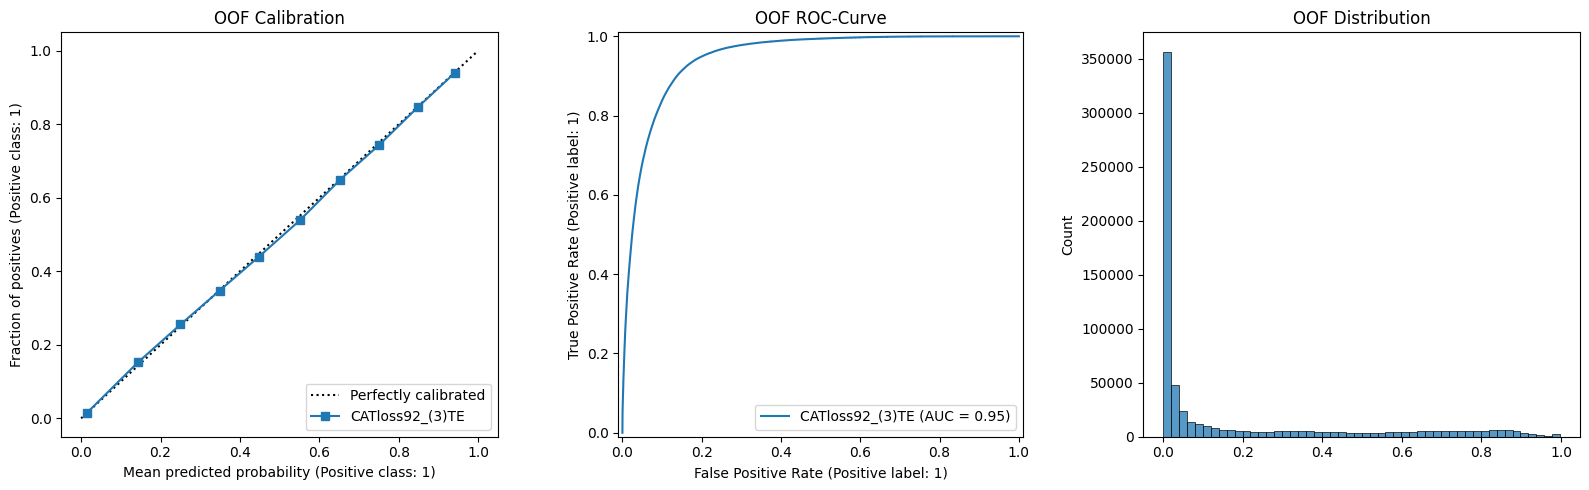

In [9]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5)) 
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=MODEL_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(y, oof_preds, name=MODEL_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

Total used features: 150



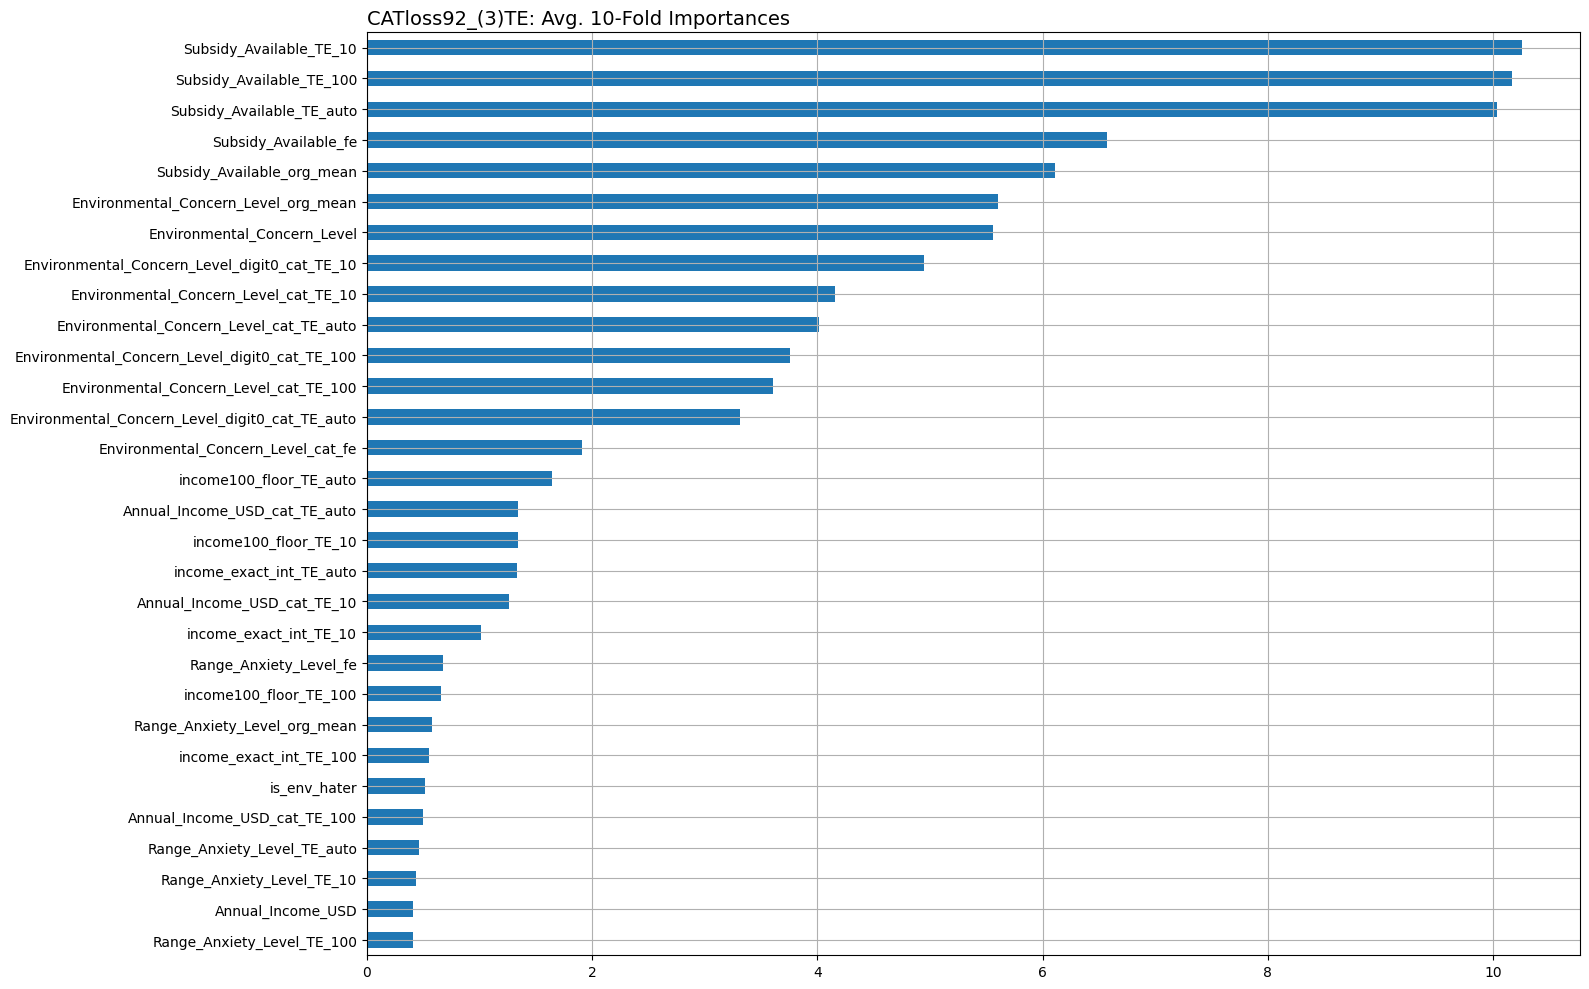

In [10]:
## -- Feature Importances --
feat_imp_df = pd.Series(np.mean(feat_importances, axis=0), index=X_valid.columns)
print(f"Total used features: {len(feat_imp_df)}\n")

ax = feat_imp_df.sort_values()[-30:].plot.barh(figsize=(16, 10))
ax.set_title(f"{MODEL_NAME}: Avg. {FOLDS}-Fold Importances", fontsize=14, loc='left')
ax.grid()

plt.tight_layout()
plt.show()

print()